In [1]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns  
from collections import Counter  
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image


# 设置matplotlib的中文字体支持，解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体，确保中文正常显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题，防止负号显示为方块

In [2]:
# 读取Excel文件
file_path = "豆瓣电影Top250.xls"  # 数据文件路径
df = pd.read_excel(file_path)  # 使用pandas读取Excel文件到DataFrame

# 数据清洗和预处理
# 将"评分"列转换为浮点数类型，便于后续数值计算
df["评分"] = df["评分"].astype(float)

# 提取"评价人数数值"字段中的数字部分
# 处理步骤：
# 1. 将数据转为字符串
# 2. 使用正则表达式提取数字（去除所有非数字字符）
# 3. 将结果转换为整数类型
df["评价人数数值"] = df["评价人数"].astype(str).str.replace(r'\D+', '', regex=True).astype(int)

# 提取"年份"字段
# 使用正则表达式提取4位数字年份，并转换为整数类型
df["年份"] = df["年份"].astype(str).str.extract(r'(\d{4})').astype(int)

# 提取"国家"字段，去掉前后空格，确保数据整洁
df["国家"] = df["国家"].str.strip()

# 提取"类型"字段，将字符串按空格分割成列表，用于后续词频统计
df["类型列表"] = df["类型"].str.split()

# 提取"导演"的中文名（假设中文名是第一个词）
df["导演中文名"] = df["导演"].str.split().str[0]

# 打印数据加载完成的信息和示例数据
print("✅ 数据加载完成，前几行示例：")
print(df.head())

✅ 数据加载完成，前几行示例：
   排名     中文名                         英文名                                其他名称  \
0   1  肖申克的救赎  / The Shawshank Redemption             / 月黑高飞(港)  /  刺激1995(台)   
1   2    霸王别姬                         NaN  / 再见，我的妾  /  Farewell My Concubine   
2   3   泰坦尼克号                   / Titanic                       / 铁达尼号(港 / 台)   
3   4    阿甘正传              / Forrest Gump                           / 福雷斯特·冈普   
4   5    千与千寻                  / 千と千尋の神隠し               / 神隐少女(台)  /  千与千寻的神隐   

                         导演                                     主演    年份  \
0   弗兰克·德拉邦特 Frank Darabont                蒂姆·罗宾斯 Tim Robbins /...  1994   
1            陈凯歌 Kaige Chen  张国荣 Leslie Cheung / 张丰毅 Fengyi Zha...  1993   
2     詹姆斯·卡梅隆 James Cameron                 莱昂纳多·迪卡普里奥 Leonardo...  1997   
3  罗伯特·泽米吉斯 Robert Zemeckis                 汤姆·汉克斯 Tom Hanks / ...  1994   
4        宫崎骏 Hayao Miyazaki          柊瑠美 Rumi Hîragi / 入野自由 Miy...  2001   

          国家        类型   评分     评价人数    

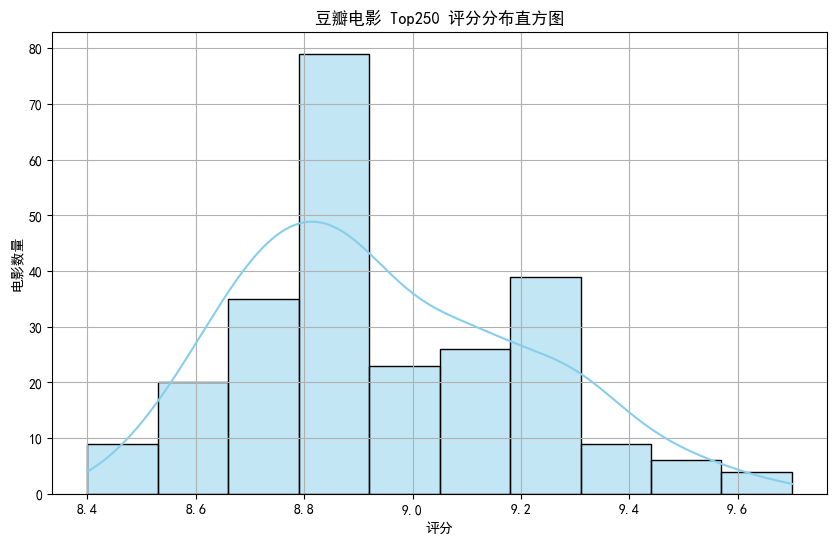

In [3]:
# ——————————————————————
# 分析一：评分分布直方图
# 目的：了解电影评分的整体分布情况
# 使用seaborn绘制评分分布的直方图，并添加核密度估计曲线
# ——————————————————————
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.histplot(df["评分"], bins=10, kde=True, color="skyblue")  # 绘制直方图和密度曲线
plt.title("豆瓣电影 Top250 评分分布直方图")
plt.xlabel("评分")
plt.ylabel("电影数量")
plt.grid(True)  # 添加网格线
plt.show()

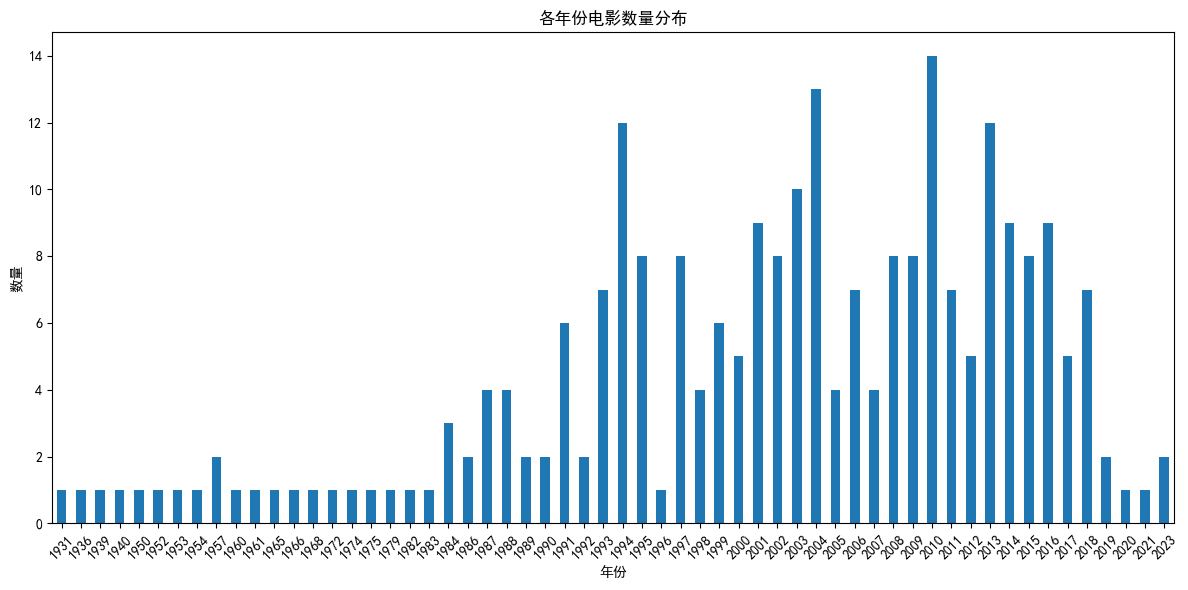

In [4]:
# ——————————————————————
# 分析二：年份趋势图
# 目的：了解电影在不同年份的分布情况
# 统计各年份的电影数量，并绘制柱状图
# ——————————————————————
year_counts = df["年份"].value_counts().sort_index()  # 统计各年份电影数量并排序
plt.figure(figsize=(12, 6))
year_counts.plot(kind='bar')  # 绘制柱状图
plt.title("各年份电影数量分布")
plt.xlabel("年份")
plt.ylabel("数量")
plt.xticks(rotation=45)  # 旋转x轴标签，防止重叠
plt.tight_layout()  # 自动调整布局
plt.show()

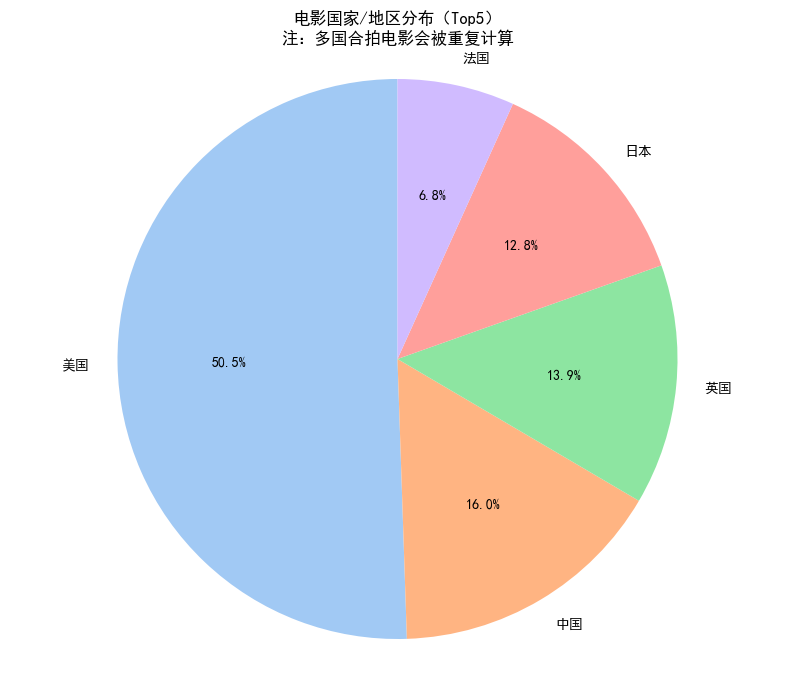


国家/地区分布详细数据：
美国    142
中国     45
英国     39
日本     36
法国     19
Name: count, dtype: int64


In [5]:
# ——————————————————————
# 分析三：国家分布（Top5）饼图
# 目的：了解电影的国家/地区分布情况，统一处理中国相关地区
# ——————————————————————
# 处理国家数据
def process_country(country_str):
    if not isinstance(country_str, str):
        return []
    
    # 定义中国相关地区的映射
    china_related = ['中国', '香港', '台湾', '大陆']
    
    # 分割并处理每个国家
    countries = []
    for country in country_str.split():
        country = country.strip()
        # 如果包含中国相关地区，统一标记为中国
        if any(region in country for region in china_related):
            country = '中国'
        if country and country not in countries:  # 确保不重复添加
            countries.append(country)
    return countries

# 展开多国家数据
all_countries = []
for countries in df['国家'].apply(process_country):
    all_countries.extend(countries)

# 统计国家出现次数
country_counts = pd.Series(all_countries).value_counts().head(5)

# 绘制饼图
plt.figure(figsize=(10, 8))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('电影国家/地区分布（Top5）\n注：多国合拍电影会被重复计算')
plt.axis('equal')  # 确保饼图是圆的
plt.show()

# 打印详细数据
print("\n国家/地区分布详细数据：")
print(country_counts)

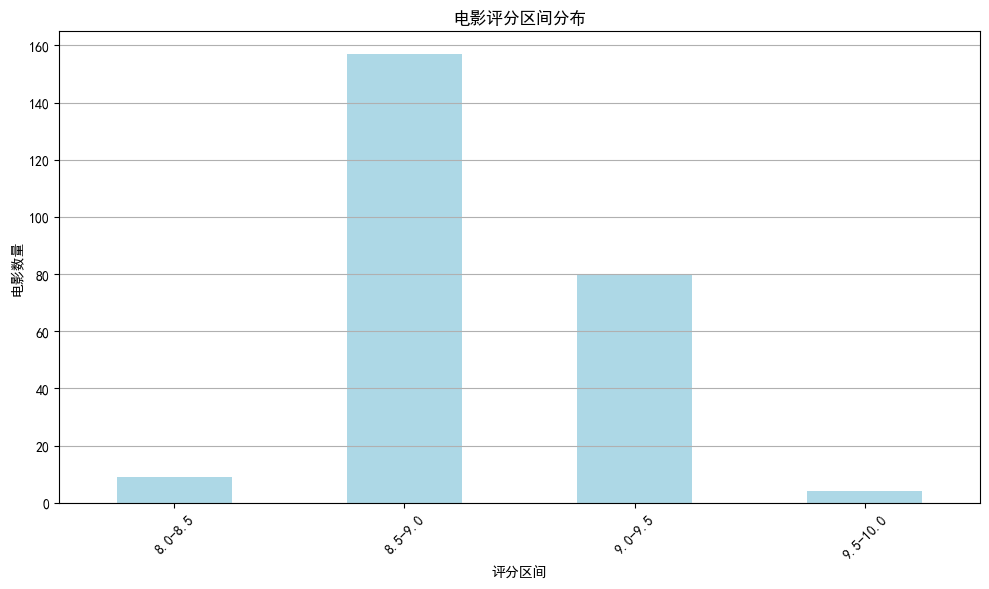

In [6]:
# ——————————————————————
# 分析四：评分区间分布
# 目的：了解电影评分的区间分布情况
# ——————————————————————
# 创建评分区间
bins = [0, 8.5, 9.0, 9.5, 10.0]
labels = ['8.0-8.5', '8.5-9.0', '9.0-9.5', '9.5-10.0']
df['评分区间'] = pd.cut(df['评分'], bins=bins, labels=labels)

# 统计各区间电影数量
score_dist = df['评分区间'].value_counts().sort_index()

# 绘制条形图
plt.figure(figsize=(10, 6))
score_dist.plot(kind='bar', color='lightblue')
plt.title('电影评分区间分布')
plt.xlabel('评分区间')
plt.ylabel('电影数量')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

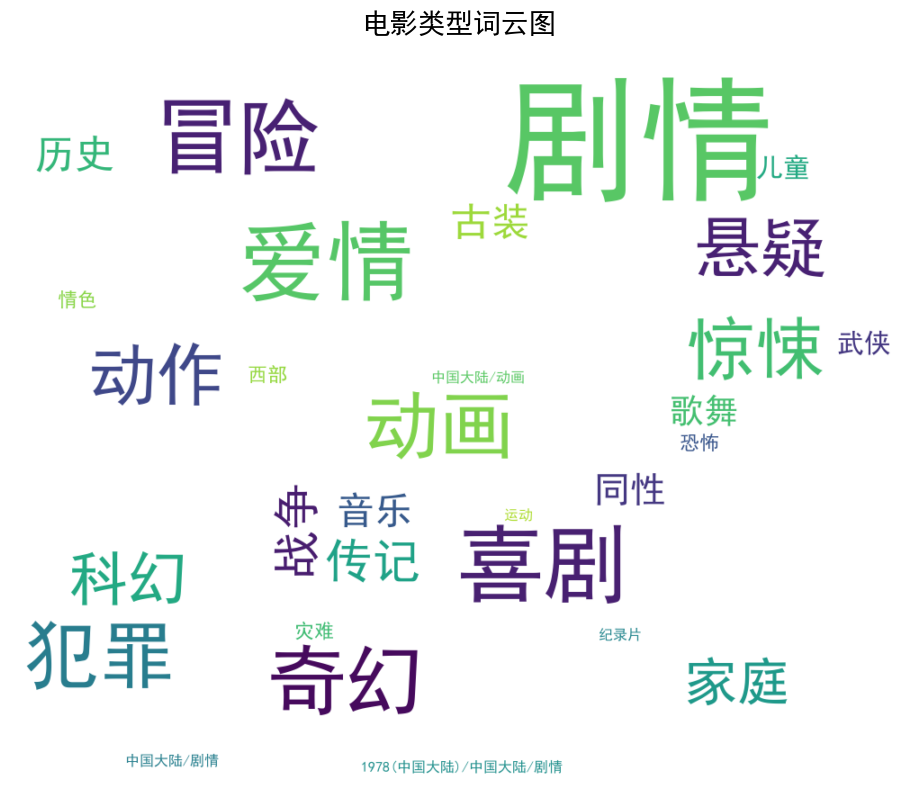


电影类型出现次数（Top10）：
剧情    184
爱情     55
喜剧     53
冒险     50
奇幻     43
犯罪     41
动画     40
惊悚     34
动作     32
悬疑     30
dtype: int64


In [7]:
# ——————————————————————
# 分析五：电影类型统计（词云图）
# 目的：了解电影类型的分布情况
# ——————————————————————
# 将所有电影类型展开成一个列表
all_genres = [genre for genres in df["类型列表"] for genre in genres]
# 使用Counter统计词频
genre_counter = Counter(all_genres)

# 创建词云图
plt.figure(figsize=(12, 8))
# 生成词云
wordcloud = WordCloud(
    font_path='simhei.ttf',  # 使用黑体字体
    width=1000,
    height=800,
    background_color='white',
    max_words=100,
    max_font_size=150,
    random_state=42
)

# 生成词云
wordcloud.generate_from_frequencies(genre_counter)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 关闭坐标轴
plt.title('电影类型词云图', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

# 打印详细数据
print("\n电影类型出现次数（Top10）：")
print(pd.Series(genre_counter).sort_values(ascending=False).head(10))

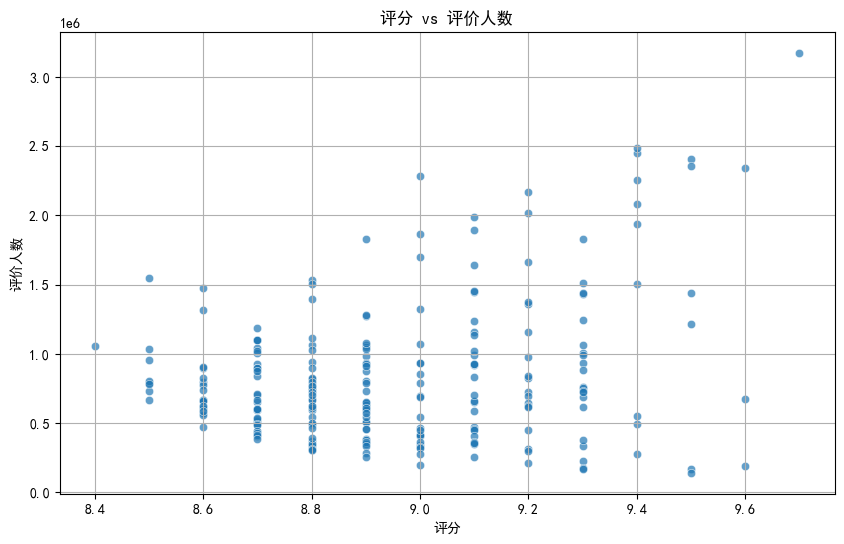

📊 分析完成！


In [8]:
# ——————————————————————
# 分析六：评分 vs 评价人数 散点图
# 目的：分析评分与评价人数之间的关系
# 使用散点图展示两个变量之间的关系
# ——————————————————————
plt.figure(figsize=(10, 6))
sns.scatterplot(x="评分", y="评价人数数值", data=df, alpha=0.7)  # 绘制散点图，设置透明度
plt.title("评分 vs 评价人数")
plt.xlabel("评分")
plt.ylabel("评价人数")
plt.grid(True)  # 添加网格线
plt.show()

print("📊 分析完成！")